In [5]:
from matplotlib import pyplot as plt
import numpy as np
import random


In [6]:
features = np.array([1,2,3,5,6,7])
labels = np.array([155, 197, 244, 356, 407, 448])

In [7]:
def line (slop, y_base, color = 'grey', alpha = 0.5, linewidth = 0.7, starting = 0, ending = 10):
  x = np.linspace(starting, ending, 1000)
  plt.plot(x, y_base+slop*x, linestyle ='-', color = color , linewidth = linewidth)

def data_points(features, labels):
  x = np.array(features)
  y = np.array(labels)
  plt.scatter(x,y)
  plt.xlabel('How meny rooms')
  plt.ylabel('cost')

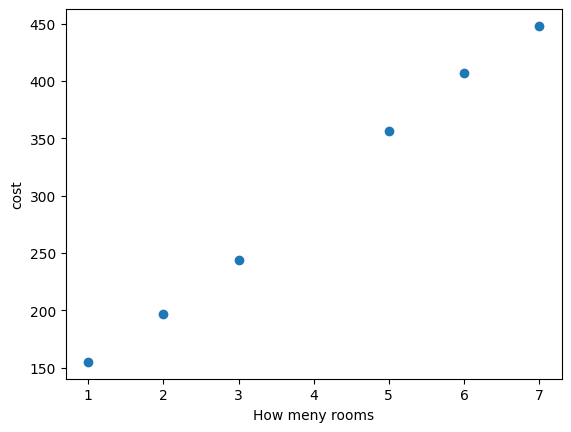

In [8]:
data_points(features, labels)

# Simple trick

In [9]:
def simple_trick(base_price, price_per_room, num_of_rooms, price):
  small_move1 = random.random()*0.1
  small_move2 = random.random()*0.1
  predicted_price = base_price + price_per_room*num_of_rooms
  if price > predicted_price and num_of_rooms > 0:
      price_per_room += small_move1
      base_price += small_move2
  if price > predicted_price and num_of_rooms < 0:
      price_per_room -= small_move1
      base_price += small_move2
  if price < predicted_price and num_of_rooms > 0:
      price_per_room -= small_move1
      base_price -= small_move2
  if price < predicted_price and num_of_rooms < 0:
      price_per_room -= small_move1
      base_price += small_move2
  return price_per_room, base_price


# Square trick

In [10]:
def square_trick(base_price, price_per_room, num_of_rooms, price, learning_rate):
    predicted_price = base_price + price_per_room*num_of_rooms  # y = b + m*x
    price_per_room += learning_rate*num_of_rooms*(price-predicted_price) # m = m + learning_rate*(y - y_hat)*x
    base_price += learning_rate*(price-predicted_price)  # b = b + learning_rate*(y - y_hat)
    return price_per_room, base_price

# Absolute trick

In [11]:
def absolute_trick(base_price, price_per_room, num_of_rooms, price, learning_rate):
    predicted_price = base_price + price_per_room*num_of_rooms
    if price > predicted_price:
        price_per_room += learning_rate*num_of_rooms
        base_price += learning_rate
    else:
        price_per_room -= learning_rate*num_of_rooms
        base_price -= learning_rate
    return price_per_room, base_price

# Running

Price per room: 51.04430678220095
Base price: 91.59448307644864


(np.float64(51.04430678220095), np.float64(91.59448307644864))

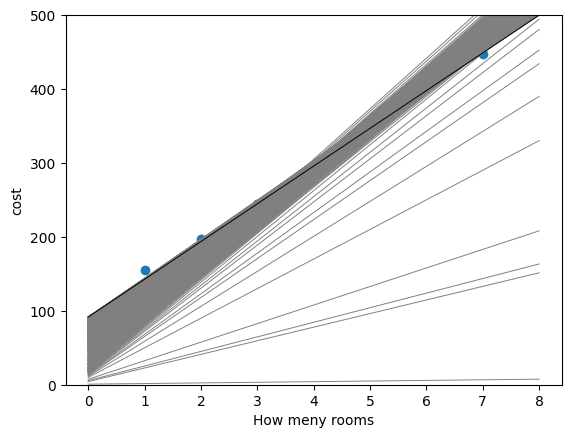

In [12]:
import random
random.seed(0)

def linear_regression(features, labels, learning_rate=0.01, epochs = 1000):
    price_per_room = random.random()
    base_price = random.random()
    for epoch in range(epochs):
        if True:
            line(price_per_room, base_price, starting=0, ending=8)
        i = random.randint(0, len(features)-1)
        num_rooms = features[i]
        price = labels[i]
        # You can choise any algorithm 
        price_per_room, base_price = square_trick(base_price,
                                                  price_per_room,
                                                  num_rooms,
                                                  price,
                                                  learning_rate=learning_rate)
    line(price_per_room, base_price, 'black', starting=0, ending=8)
    data_points(features, labels)
    print('Price per room:', price_per_room)
    print('Base price:', base_price)
    return price_per_room, base_price

plt.ylim(0,500)

linear_regression(features, labels, learning_rate = 0.01, epochs = 1000)

# The root mean square error function

In [13]:
def rmse(labels, predictions):
    n = len(labels)
    differences = np.subtract(labels, predictions)
    return np.sqrt(1.0/n * (np.dot(differences, differences)))

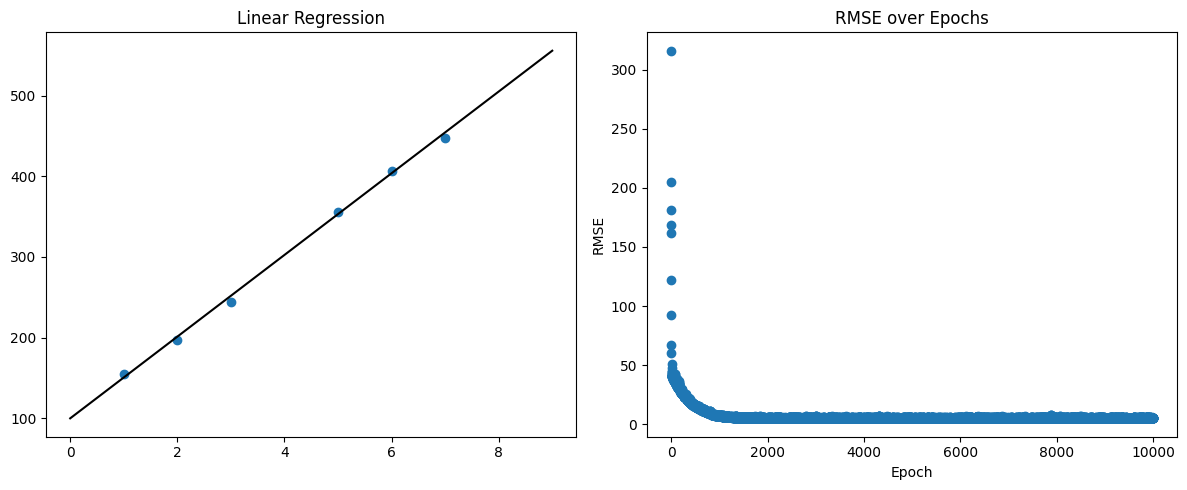

Price per room: 50.65781332767556
Base price: 99.79504258184782


(np.float64(50.65781332767556), np.float64(99.79504258184782))

In [15]:
def linear_regression(features, labels, learning_rate=0.01, epochs=1000):

    price_per_room = random.random()
    base_price = random.random()
    errors = []
    for i in range(epochs):
        predictions = features * price_per_room + base_price
        errors.append(rmse(labels, predictions))
        i = random.randint(0, len(features)-1)
        num_rooms = features[i]
        price = labels[i]
        price_per_room, base_price = square_trick(
            base_price,
            price_per_room,
            num_rooms,
            price,
            learning_rate=learning_rate
        )
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    # First plot
    x = np.linspace(0, 9, 1000)
    ax[0].plot(
        x,
        base_price + price_per_room * x,
        color='black'
    )
    ax[0].scatter(features, labels)
    ax[0].set_title('Linear Regression')
    # Second plot
    ax[1].scatter(range(len(errors)), errors)
    ax[1].set_title('RMSE over Epochs')
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('RMSE')
    plt.tight_layout()
    plt.show()
    print('Price per room:', price_per_room)
    print('Base price:', base_price)
    return price_per_room, base_price

linear_regression(features, labels, learning_rate = 0.01, epochs = 10000)